In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [5]:
df = pd.read_csv("../data/processed/ratnapark/ratnapark_2016_2020_raw.csv")
df["date"] = pd.to_datetime(df["date"])

print("Shape:", df.shape)
display(df.head())

Shape: (43824, 6)


,date,pm1,year,pm2_5,pm10,tsp
0,2016-01-01,NaN,2016,NaN,NaN,NaN
1,2016-01-01,NaN,2016,NaN,NaN,NaN
2,2016-01-01,NaN,2016,NaN,NaN,NaN
3,2016-01-01,NaN,2016,NaN,NaN,NaN
4,2016-01-01,NaN,2016,NaN,NaN,NaN


In [6]:
df = df[["date", "pm1", "pm2_5", "pm10"]].copy()

display(df.head())

,date,pm1,pm2_5,pm10
0,2016-01-01,NaN,NaN,NaN
1,2016-01-01,NaN,NaN,NaN
2,2016-01-01,NaN,NaN,NaN
3,2016-01-01,NaN,NaN,NaN
4,2016-01-01,NaN,NaN,NaN


In [8]:
df_daily = (df.set_index("date")[["pm1", "pm2_5", "pm10"]].resample("D").mean().reset_index())
display(df_daily.head())

,date,pm1,pm2_5,pm10
0,2016-01-01,NaN,NaN,NaN
1,2016-01-02,NaN,NaN,NaN
2,2016-01-03,NaN,NaN,NaN
3,2016-01-04,NaN,NaN,NaN
4,2016-01-05,NaN,NaN,NaN


In [9]:
pm1_daily_complete = df_daily.dropna(subset=["pm1", "pm2_5", "pm10"]).copy()

print("Original daily rows:", len(df_daily))
print("Complete daily rows:", len(pm1_daily_complete))
print("Removed rows:", len(df_daily) - len(pm1_daily_complete))

display(pm1_daily_complete.head())

Original daily rows: 1826
Complete daily rows: 1313
Removed rows: 513


,date,pm1,pm2_5,pm10
237,2016-08-25,144.026083,187.599837,269.346300
239,2016-08-27,121.881565,159.537520,230.975440
240,2016-08-28,98.196717,124.696523,171.362190
241,2016-08-29,54.083770,63.915300,78.042140
250,2016-09-07,127.947061,168.501950,245.585955


In [10]:
X = pm1_daily_complete[["pm2_5", "pm10"]]
y = pm1_daily_complete["pm1"]

In [11]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2, random_state=42)
print("Training samples are ", len(X_train))
print("Testing samples are ", len(X_test))


Training samples are  1050
Testing samples are  263


In [13]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ 1.34,-0.4 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['pm2_5','pm10']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.6737
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [14]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[ 78.16829725  56.04426465 180.29382811 114.17158312  24.79511735
  86.72595593 176.20161232 146.9392673   19.04153667 151.91982234]


In [15]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R²  :", round(r2, 3))

MAE : 1.322
RMSE: 2.21
R²  : 0.999


In [16]:
print("Intercept:", model.intercept_)

print("PM2.5 coefficient:", model.coef_[0])
print("PM10 coefficient:", model.coef_[1])

Intercept: 0.6736553156158749
PM2.5 coefficient: 1.338457311157915
PM10 coefficient: -0.3954990938671837


In [17]:
results = pd.DataFrame({
    "Actual_PM1": y_test.values,
    "Predicted_PM1": y_pred
})

display(results.head(20))

,Actual_PM1,Predicted_PM1
0,77.311718,78.168297
1,55.778595,56.044265
2,180.008363,180.293828
3,116.530485,114.171583
4,25.131178,24.795117
5,85.101278,86.725956
6,174.719910,176.201612
7,144.660365,146.939267
8,18.733480,19.041537
9,151.245373,151.919822


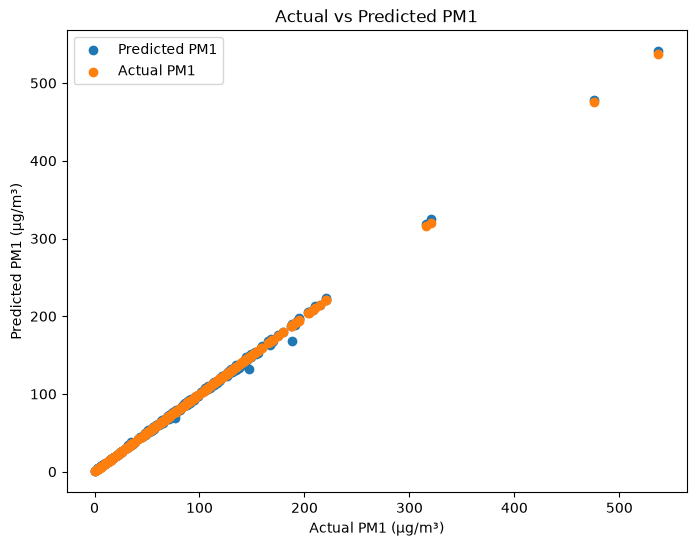

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test,y_pred,label="Predicted PM1")

plt.scatter(y_test,y_test,label="Actual PM1")

plt.xlabel("Actual PM1 (µg/m³)")
plt.ylabel("Predicted PM1 (µg/m³)")
plt.title("Actual vs Predicted PM1")

plt.legend()
plt.show()

## Randomly spliting data sounds cool but lets split year wise and find out 

In [22]:
train = pm1_daily_complete[pm1_daily_complete["date"].dt.year <= 2019]

test = pm1_daily_complete[pm1_daily_complete["date"].dt.year == 2020]

In [23]:
X_train = train[["pm2_5", "pm10"]]
y_train = train["pm1"]

X_test = test[["pm2_5", "pm10"]]
y_test = test["pm1"]

In [24]:
model_time = LinearRegression()

model_time.fit(X_train, y_train)

y_pred = model_time.predict(X_test)

In [25]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R²  :", round(r2, 3))

MAE : 1.55
RMSE: 2.534
R²  : 0.997


### Now after chekcing random and year like data split , we are ready to fill data to 2024 and 2025 data with pm1 values 

In [30]:
df_2024 = pd.read_csv("../data/processed/ratnapark/ratnapark_2024_raw.csv")

df_2025 = pd.read_csv("../data/processed/ratnapark/ratnapark_2025_raw.csv")

df_2024["date"] = pd.to_datetime(df_2024["date"])
df_2025["date"] = pd.to_datetime(df_2025["date"])

print("2024:", df_2024.shape)
print("2025:", df_2025.shape)

2024: (366, 4)
2025: (365, 4)


In [31]:
display(df_2024.head())
display(df_2025.head())

,date,PM2.5,PM10,TSP
0,2024-01-01,90.775476,143.765236,NaN
1,2024-01-02,67.563681,115.420000,NaN
2,2024-01-03,75.885651,124.428044,NaN
3,2024-01-04,71.930000,124.660417,NaN
4,2024-01-05,71.616645,120.349614,NaN


,date,PM2.5,PM10,TSP
0,2025-01-01,84.267297,107.604443,144.710756
1,2025-01-02,75.462222,98.918750,139.656319
2,2025-01-03,76.425871,103.150620,137.181622
3,2025-01-04,77.286875,101.310278,130.651111
4,2025-01-05,96.779076,126.563356,152.271662


In [32]:
print("2024 columns:")
print(df_2024.columns.tolist())

print("\n2025 columns:")
print(df_2025.columns.tolist())

2024 columns:
['date', 'PM2.5', 'PM10', 'TSP']

2025 columns:
['date', 'PM2.5', 'PM10', 'TSP']


In [38]:
df_2024["pm2_5"] = pd.to_numeric(df_2024["PM2.5"], errors="coerce")
df_2024["pm10"] = pd.to_numeric(df_2024["PM10"], errors="coerce")

df_2025["pm2_5"] = pd.to_numeric(df_2025["PM2.5"], errors="coerce")
df_2025["pm10"] = pd.to_numeric(df_2025["PM10"], errors="coerce")

In [39]:
df_2024["PM1"] = np.nan
df_2025["PM1"] = np.nan

In [40]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("Missing X:")
print(X.isna().sum())

print("Missing y:")
print(y.isna().sum())

X shape: (1313, 2)
y shape: (1313,)
Missing X:
pm2_5    0
pm10     0
dtype: int64
Missing y:
0


In [41]:
final_model = LinearRegression()

final_model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ 1.34,-0.39]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['pm2_5','pm10']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.6898
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [42]:
print("Final model trained on:", len(X), "observations")

print("Intercept:", final_model.intercept_)
print("PM2.5 coefficient:", final_model.coef_[0])
print("PM10 coefficient:", final_model.coef_[1])

Final model trained on: 1313 observations
Intercept: 0.6897776827080264
PM2.5 coefficient: 1.336306174493211
PM10 coefficient: -0.39398867716666003


In [44]:
mask_2024 = df_2024[["pm2_5", "pm10"]].notna().all(axis=1)

df_2024.loc[mask_2024, "PM1"] = final_model.predict(
    df_2024.loc[mask_2024, ["pm2_5", "pm10"]])

In [46]:
mask_2025 = df_2025[["pm2_5", "pm10"]].notna().all(axis=1)

df_2025.loc[mask_2025, "PM1"] = final_model.predict(
    df_2025.loc[mask_2025, ["pm2_5", "pm10"]])

In [47]:
print("2024")
print("Total rows:", len(df_2024))
print("PM1 predicted:", df_2024["PM1"].notna().sum())
print("PM1 remaining missing:", df_2024["PM1"].isna().sum())

print("\n2025")
print("Total rows:", len(df_2025))
print("PM1 predicted:", df_2025["PM1"].notna().sum())
print("PM1 remaining missing:", df_2025["PM1"].isna().sum())

2024
Total rows: 366
PM1 predicted: 268
PM1 remaining missing: 98

2025
Total rows: 365
PM1 predicted: 306
PM1 remaining missing: 59


In [49]:
display(
    df_2024[["date", "PM2.5", "PM10", "PM1"]].head())

,date,PM2.5,PM10,PM1
0,2024-01-01,90.775476,143.765236,65.351732
1,2024-01-02,67.563681,115.420000,45.501368
2,2024-01-03,75.885651,124.428044,53.073001
3,2024-01-04,71.930000,124.660417,47.695488
4,2024-01-05,71.616645,120.349614,48.975158


In [50]:
display(
    df_2025[["date", "PM2.5", "PM10", "PM1"]].head())

,date,PM2.5,PM10,PM1
0,2025-01-01,84.267297,107.604443,70.901755
1,2025-01-02,75.462222,98.918750,62.557544
2,2025-01-03,76.425871,103.150620,62.177964
3,2025-01-04,77.286875,101.310278,64.053604
4,2025-01-05,96.779076,126.563356,80.151725


### After we masked with 2024 and 2025 data , lets us combine all those data to form a new csv with zero misisng values and work onto that 

In [51]:
historical = df_daily[["date", "pm1", "pm2_5", "pm10"]].copy()

In [52]:
data_2024 = df_2024[["date", "PM1", "PM2.5", "PM10"]].copy()

data_2024 = data_2024.rename(columns={
        "PM1": "pm1",
        "PM2.5": "pm2_5",
        "PM10": "pm10"
    }
)

In [53]:
data_2025 = df_2025[["date", "PM1", "PM2.5", "PM10"]].copy()

data_2025 = data_2025.rename(
    columns={
        "PM1": "pm1",
        "PM2.5": "pm2_5",
        "PM10": "pm10"
    }
)

In [54]:
combined = pd.concat(
    [
        historical,
        data_2024,
        data_2025
    ],
    ignore_index=True
)

In [55]:
combined = combined.sort_values("date").reset_index(drop=True)

In [57]:
combined_complete = combined.dropna(subset=["pm1", "pm2_5", "pm10"]).copy()

In [58]:
combined_complete.head()

,date,pm1,pm2_5,pm10
237,2016-08-25,144.026083,187.599837,269.346300
239,2016-08-27,121.881565,159.537520,230.975440
240,2016-08-28,98.196717,124.696523,171.362190
241,2016-08-29,54.083770,63.915300,78.042140
250,2016-09-07,127.947061,168.501950,245.585955


In [59]:
print("Before removing incomplete rows:", len(combined))
print("After removing incomplete rows:", len(combined_complete))

display(combined_complete.head())
display(combined_complete.tail())

Before removing incomplete rows: 2557
After removing incomplete rows: 1887


,date,pm1,pm2_5,pm10
237,2016-08-25,144.026083,187.599837,269.346300
239,2016-08-27,121.881565,159.537520,230.975440
240,2016-08-28,98.196717,124.696523,171.362190
241,2016-08-29,54.083770,63.915300,78.042140
250,2016-09-07,127.947061,168.501950,245.585955


,date,pm1,pm2_5,pm10
2552,2025-12-27,62.634761,73.584236,92.353125
2553,2025-12-28,59.609465,70.560069,89.774583
2554,2025-12-29,60.442938,70.737011,88.259249
2555,2025-12-30,62.676937,75.665342,99.304639
2556,2025-12-31,59.515977,73.188123,98.925535


In [60]:
print(combined_complete[["pm1", "pm2_5", "pm10"]].isna().sum())

pm1      0
pm2_5    0
pm10     0
dtype: int64


In [61]:
output_path = "../data/processed/ratnapark/ratnapark_pm1_pm25_pm10_daily.csv"

combined_complete.to_csv( output_path,index=False)

print(f"Saved: {output_path}")

Saved: ../data/processed/ratnapark/ratnapark_pm1_pm25_pm10_daily.csv
